Clase 5 Foro Obligatorio
Tomaremos un conjunto de datos que nos interese trabajar y mediante la implementación de los algoritmos Árbol de Decisión y K-NN, evaluaremos y compararemos la precisión de los clasificadores generados. 

Tomamos de Kaggle un dataset para predicción de Infartos.

Dataset
Stroke Prediction Dataset
11 clinical features for predicting stroke events

Context
According to the World Health Organization (WHO) stroke is the 2nd leading cause of death globally, responsible for approximately 11% of total deaths. This dataset is used to predict whether a patient is likely to get stroke based on the input parameters like gender, age, various diseases, and smoking status. Each row in the data provides relavant information about the patient.

Attribute Information
1) id: unique identifier
2) gender: "Male", "Female" or "Other"
3) age: age of the patient
4) hypertension: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
5) heart_disease: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
6) ever_married: "No" or "Yes"
7) work_type: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8) Residence_type: "Rural" or "Urban"
9) avg_glucose_level: average glucose level in blood
10) bmi: body mass index
11) smoking_status: "formerly smoked", "never smoked", "smokes" or "Unknown"
12) stroke: 1 if the patient had a stroke or 0 if not
*Note: "Unknown" in smoking_status means that the information is unavailable for this patient


Variables seleccionadas:
Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level'], dtype='object')

Mejores parámetros Arbol de Decisión:
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 6}

Mejor score:
0.8570533760957586

Métricas Árbol de Decisión:
              precision    recall  f1-score   support

  No Infarto       0.98      0.81      0.88      1458
     Infarto       0.15      0.67      0.25        75

    accuracy                           0.80      1533
   macro avg       0.56      0.74      0.56      1533
weighted avg       0.94      0.80      0.85      1533



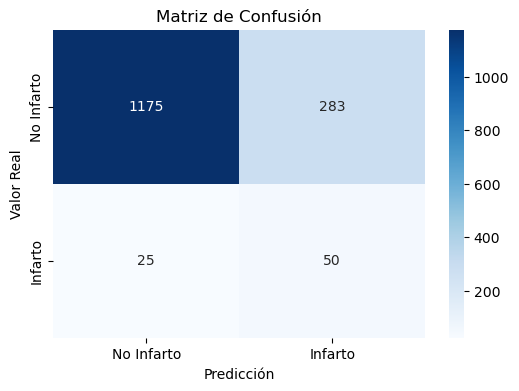


Importancia de Variables Arbol de decisión:
            Variable  Importancia
0                age     0.854205
3  avg_glucose_level     0.120111
1       hypertension     0.017909
2      heart_disease     0.007775


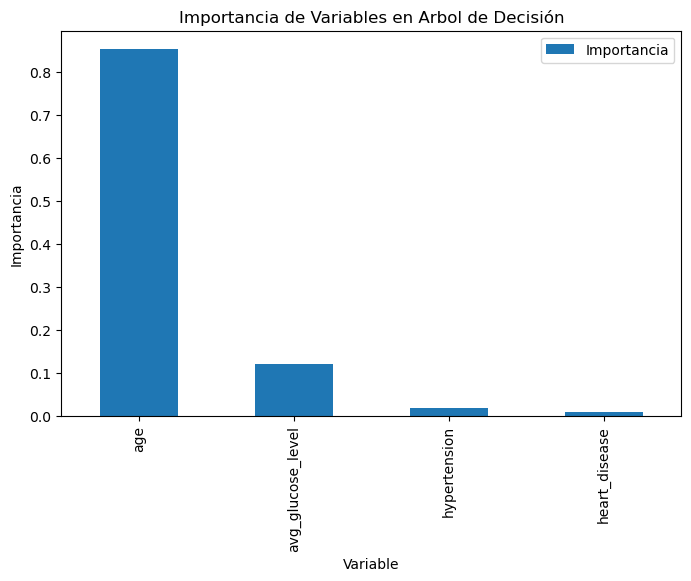


Mejores parámetros KNN:
{'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}

Mejor score:
0.8680476583173802

Métricas KNN:
              precision    recall  f1-score   support

  No Infarto       0.97      0.81      0.88      1458
     Infarto       0.14      0.59      0.22        75

    accuracy                           0.80      1533
   macro avg       0.56      0.70      0.55      1533
weighted avg       0.93      0.80      0.85      1533



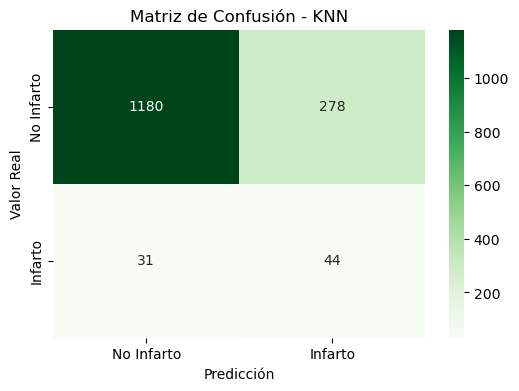


Importancia de Variables KNN:
            Variable  Importancia
0                age     0.021070
3  avg_glucose_level     0.004762
2      heart_disease    -0.000196
1       hypertension    -0.001305


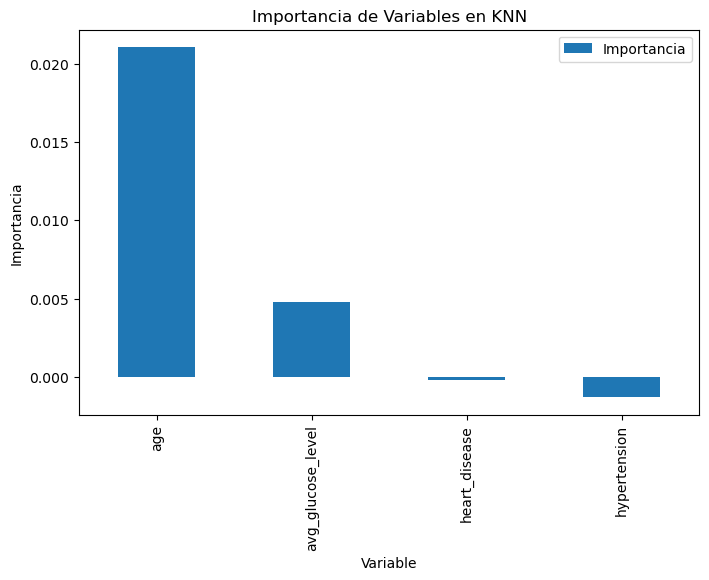

In [7]:
# Vamos a arrancar de cero
# Hasta ahora la clase dominante sigue siendo la favorecida.
# Buscando y preguntando encontré que SMOTE es una técnica de creación de registros sintéticos a partir de los registros exitentes.
# Esta función fue creada específicamente para lidiar con situaciones de fuertes desbalanceos como nos pasa en esta ocasion.

# importación de librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, confusion_matrix

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.inspection import permutation_importance

# Importación de Archivo CSV (Comma-Separated Values)

datos_csv = pd.read_csv(r"C:\Users\orlan\OneDrive\Documents\Tecnicatura\2A1C - Aprendizaje Automatico\Semana 5\healthcare-dataset-stroke-data.csv", encoding= "ISO-8859-1")
# print("Archivo CSV") (al hacerlo todo de un tirón, queda colgado
# datos_csv.head() (al hacerlo todo de un tirón, queda colgado

# Preparación de X e y

X = datos_csv.drop("stroke", axis=1)
y = datos_csv["stroke"]

# En la instancia original identificamos que bmi tenía registros NaN.
# Reemplazamos los NaN con la mediana. Por lo que leí es lo más conveniente para no perder registros.

imputer = SimpleImputer(strategy="median")
X[["bmi"]] = imputer.fit_transform(X[["bmi"]])

# Vamos a convertir las variables categóricas del dataset original en columnas binarias.
# Se podrían convertir en codificación por etiquetas (1,2,3,...) pero el modelo podría asumir que alguna es mayor que otra.
# Lo que es cierto es que aumenta la cantidad de dimensiones del dataset original
# Voy a dejar el drop_first en False para que no perdamos datos, aún no se qué variables vamos a seleccionar

X = pd.get_dummies(X,drop_first=False)

# Ahora el conjunto de datos está listo!

# Vamos a usar SelectKBest para ver las variables más relevantes.

selector = SelectKBest(score_func=f_classif,k=4)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Variables seleccionadas:")
print(selected_features)

# División de entrenamiento y prueba
# stratify=y para mantener la misma proporción de clases que el dataset original

X_train, X_test, y_train, y_test = train_test_split(X_selected,y,test_size=0.3,random_state=42,stratify=y)

# Vamos a escalar los datos
# Es necesario para el modelo KNN, y no sería necesario para el Arbol de Decisión.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Vamos a aplicar el SMOTE para generar datos sintéticos para contrarrestar el desbalanceo.
# Se hace solo al conjunto de entrenamiento, no al test.

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled,y_train)

# Modelo Arbol de Decisión
# -----------------------------------------------------------------------------------------------

# Vamos a buscar los mejores hiperparámetros para el modelo de Arbol de Decisión con GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2,11),
    'min_samples_split': range(2,11),
    'min_samples_leaf': range(1,6)
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_tree.fit(
    X_train_resampled,
    y_train_resampled
)

# Los mejores hiperparametros para el Arbol de decisión son los siguientes:

print("\nMejores hiperparámetros Arbol de Decisión:")
print(grid_tree.best_params_)

print("\nMejor score:")
print(grid_tree.best_score_)

# Cargamos los mejores parametros

best_tree = grid_tree.best_estimator_

# Ejecutamos el modelo con los mejores parametros

y_pred = best_tree.predict(X_test_scaled)

# Vemos las métricas del Arbol de Decisión

print("\nMétricas Árbol de Decisión:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Infarto",
            "Infarto"
        ],
        zero_division=0
    )
)

# Matriz de confusión del Arbol de decisión

cm_AdD = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm_AdD,annot=True,fmt="d",cmap="Blues",xticklabels=["No Infarto","Infarto"], yticklabels=["No Infarto","Infarto"])

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")

plt.show()

# Mostramos la relevancia de las variables en la definición del Arbol de Decisión

importance_AdD = pd.DataFrame({'Variable': selected_features,'Importancia': best_tree.feature_importances_})

importance_AdD = importance_AdD.sort_values(by='Importancia',ascending=False)

print("\nImportancia de Variables Arbol de decisión:")
print(importance_AdD)

# Graficamos

importance_AdD.plot(
    x='Variable',
    y='Importancia',
    kind='bar',
    figsize=(8,5)
)

plt.title("Importancia de Variables en Arbol de Decisión")
plt.ylabel("Importancia")

plt.show()




# Modelo KNN
# -----------------------------------------------------------------------------------------------

# Vamos a buscar los mejores hiperparámetros para el modelo de Arbol de Decisión con GridSearchCV

param_grid = {
    'n_neighbors': range(1,15),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_knn.fit(
    X_train_resampled,
    y_train_resampled
)

# Los mejores hiperparametros para KNN son los siguientes:

print("\nMejores hiperparámetros KNN:")
print(grid_knn.best_params_)

print("\nMejor score:")
print(grid_knn.best_score_)

# Cargamos los mejores parametros

best_knn = grid_knn.best_estimator_

# Ejecutamos el modelo con los mejores parametros

y_pred = best_knn.predict(X_test_scaled)

# Vemos las métricas de KNN

print("\nMétricas KNN:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Infarto",
            "Infarto"
        ],
        zero_division=0
    )
)

# Matriz de confusión de KNN

cm_knn = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm_knn,annot=True,fmt="d",cmap="Greens",xticklabels=["No Infarto","Infarto"],yticklabels=["No Infarto","Infarto"])

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - KNN")

plt.show()

# Mostramos la relevancia de las variables en la definición de KNN
# KNN no permite evaluar la importancia de las variables desde el modelo, hay que hacerlo externamente

result = permutation_importance(
    best_knn,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_knn = pd.DataFrame({
    'Variable': selected_features,
    'Importancia': result.importances_mean
})

importance_knn = importance_knn.sort_values(
    by='Importancia',
    ascending=False
)

print("\nImportancia de Variables KNN:")
print(importance_knn)

# Graficamos

importance_knn.plot(
    x='Variable',
    y='Importancia',
    kind='bar',
    figsize=(8,5)
)

plt.title("Importancia de Variables en KNN")
plt.ylabel("Importancia")

plt.show()

